# [LAB-06] 2-1. Line Plot 기본 구조

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import my_plot
import seaborn as sb

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


## #02. Seaborn 그래프 패턴별 LinePlot

### 1. 자동 인식 패턴

- 그래프에 표시될 연속성 데이터(list, ndarray, Series)를 설정한다. 
- 값은 `y`축이 되고, 인덱스는 `x`축이 된다.

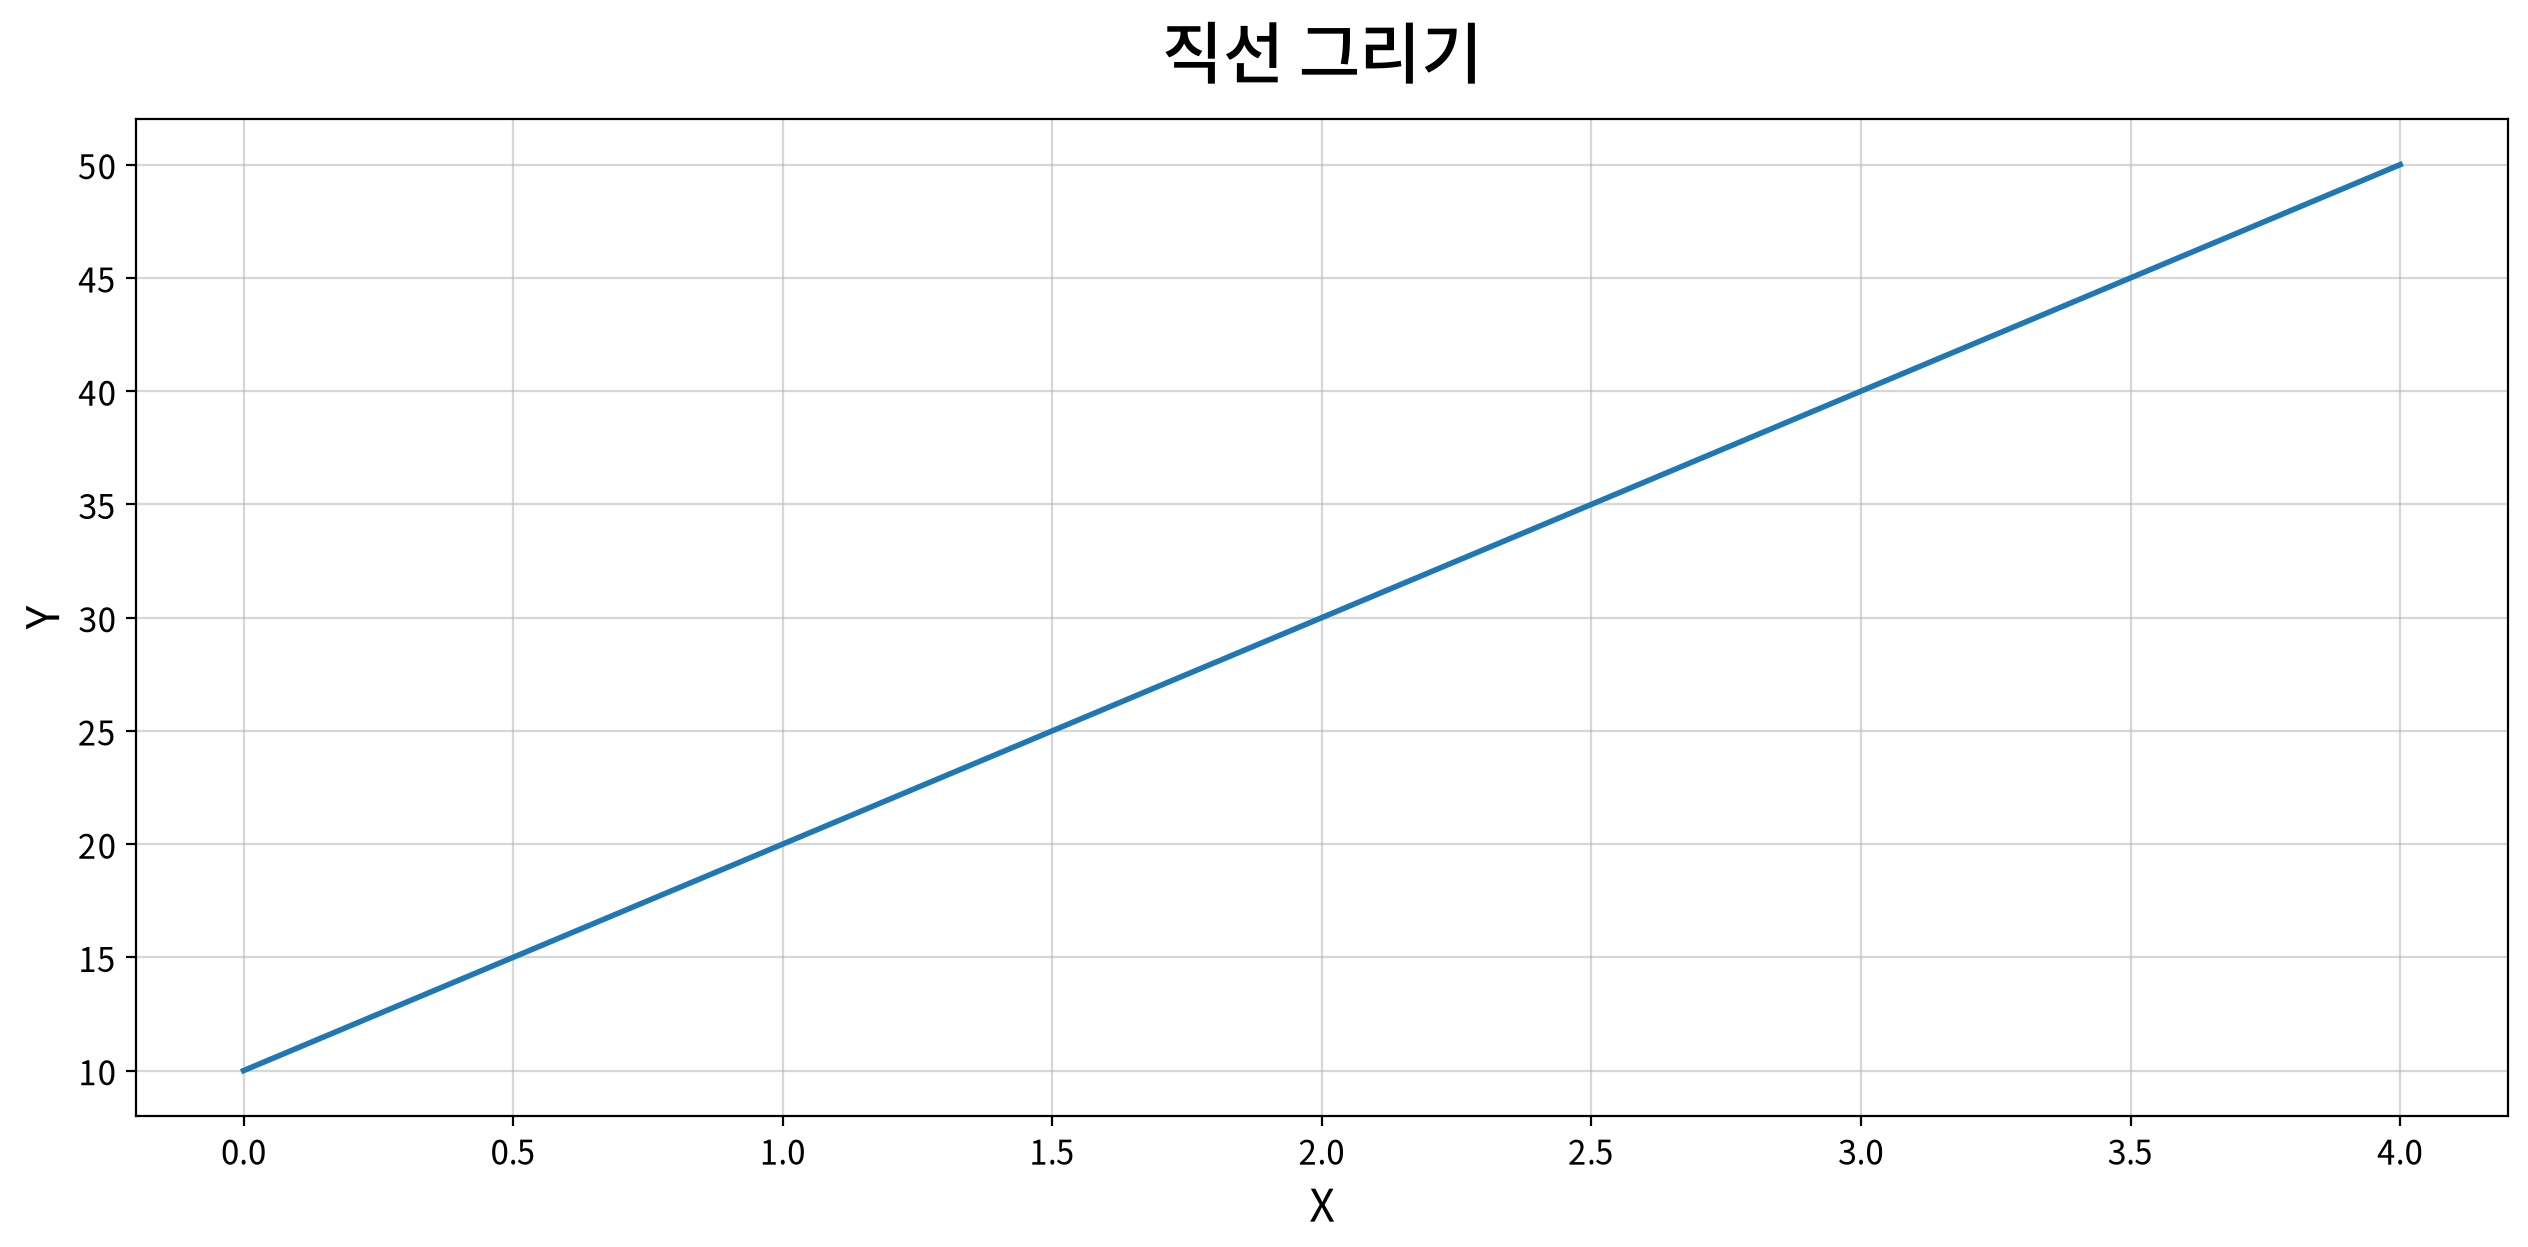

In [2]:
# 그래프 초기화
fig, ax = my_plot.init(title="직선 그리기", xlabel="X", ylabel="Y")

# 그래프 그리기 (직선 그리기)
sb.lineplot([10, 20, 30, 40, 50])

# 출력
my_plot.show()

### 2. 개별 데이터 직접 지정 패턴

- `x`축의 데이터와 `y`축의 데이터를 직접 지정한다.
  - `Series, list, nbarray`등의 연속성 데이터를 사용할 수 있다.

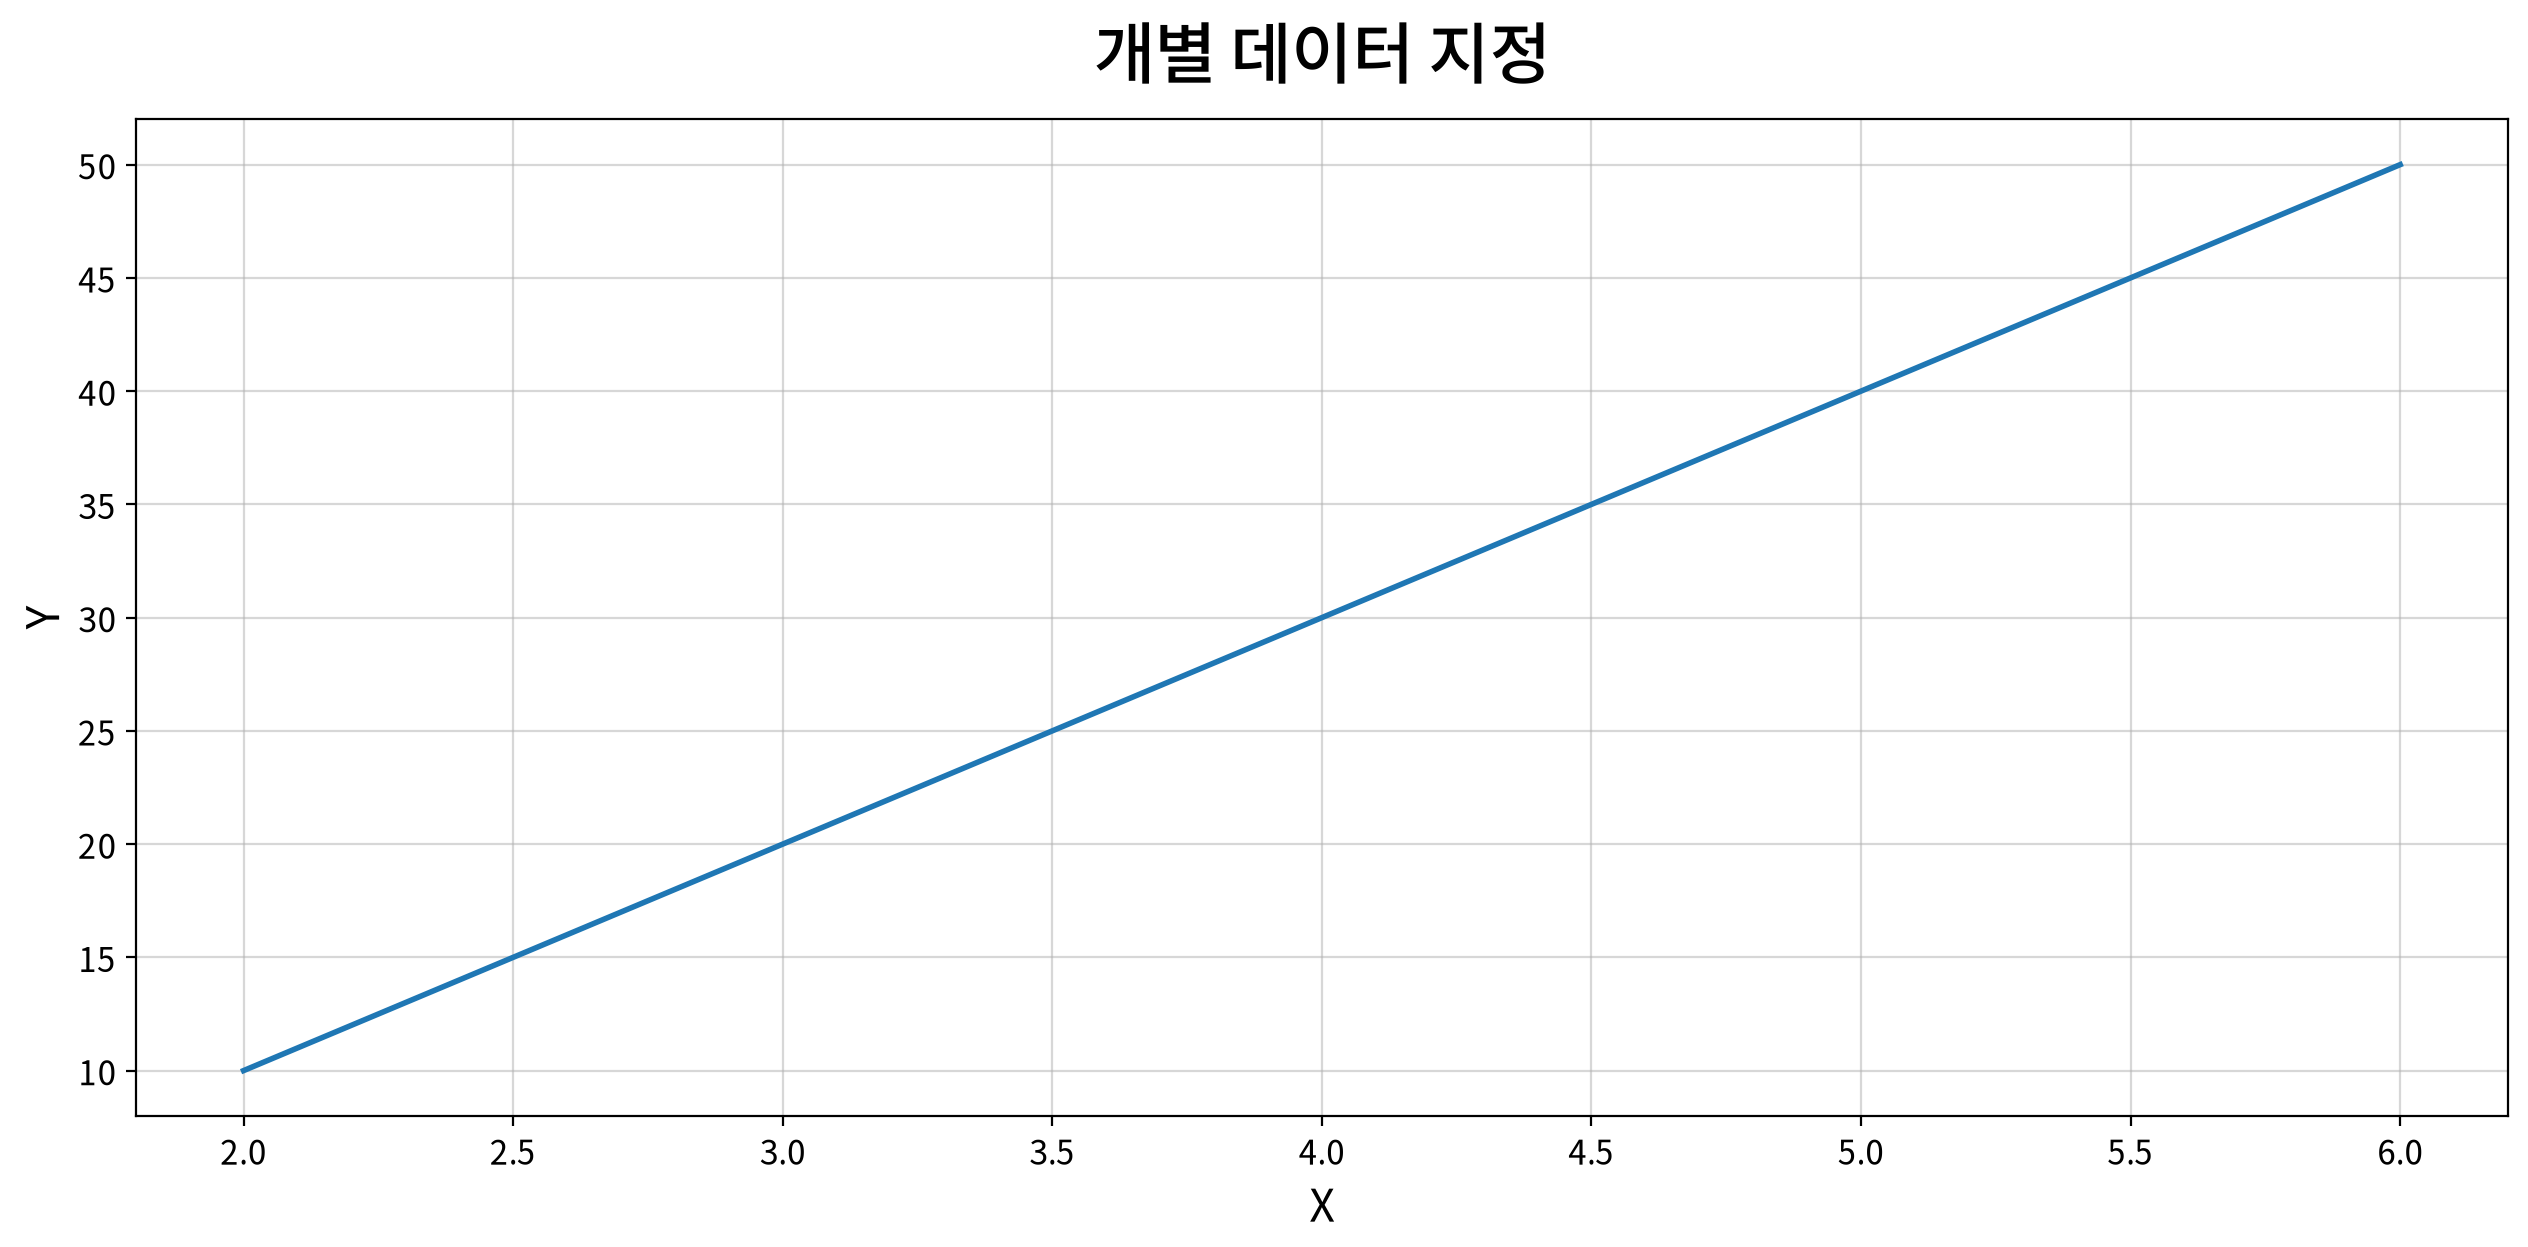

In [3]:
# 그래프 초기화
fig, ax = my_plot.init(title="개별 데이터 지정", xlabel="X", ylabel="Y")

# 그래프 그리기
sb.lineplot(x=[2, 3, 4, 5, 6], y=[10, 20, 30, 40, 50])

# 출력
my_plot.show()

### 3. DataFrame + 컬럼명 패턴을 위한 데이터 불러오기

In [4]:
origin = load_data('icecream_sales')
origin

📚 '달콤 스쿱' 아이스크림 가게의 매출 데이터 (인덱스 없음)


,Date,Flavor,Topping,Price,Quantity
0,2023-07-01,초콜릿,아몬드,3500,20.000
1,2023-07-01,바닐라,초코시럽,3000,25.000
2,2023-07-01,딸기,연유,3200,18.000
3,2023-07-02,민트초코,초코칩,3800,15.000
4,2023-07-02,초콜릿,아몬드,3500,22.000
5,2023-07-02,바닐라,None,3000,30.000
6,2023-07-03,딸기,연유,3200,25.000
7,2023-07-03,민트초코,초코칩,3800,NaN
8,2023-07-03,바닐라,초코시럽,3000,28.000
9,2023-07-04,초콜릿,아몬드,3500,18.000


### 4. DataFrame + 컬럼명 패턴

- **seaborn 사용시 가장 권장되는 방식**
  - 데이터 프레임을 사용하는 경우만 가능
  - `hue` 파라미터에 범주형 변수를 설정하여 특정 변수별로 데이터를 구분하여 시각화 할 수 있다.
  - 컬럼명 대신에 DataFrame의 `index`를 직접 지정할 수 있다.
    - 예) `df.index`

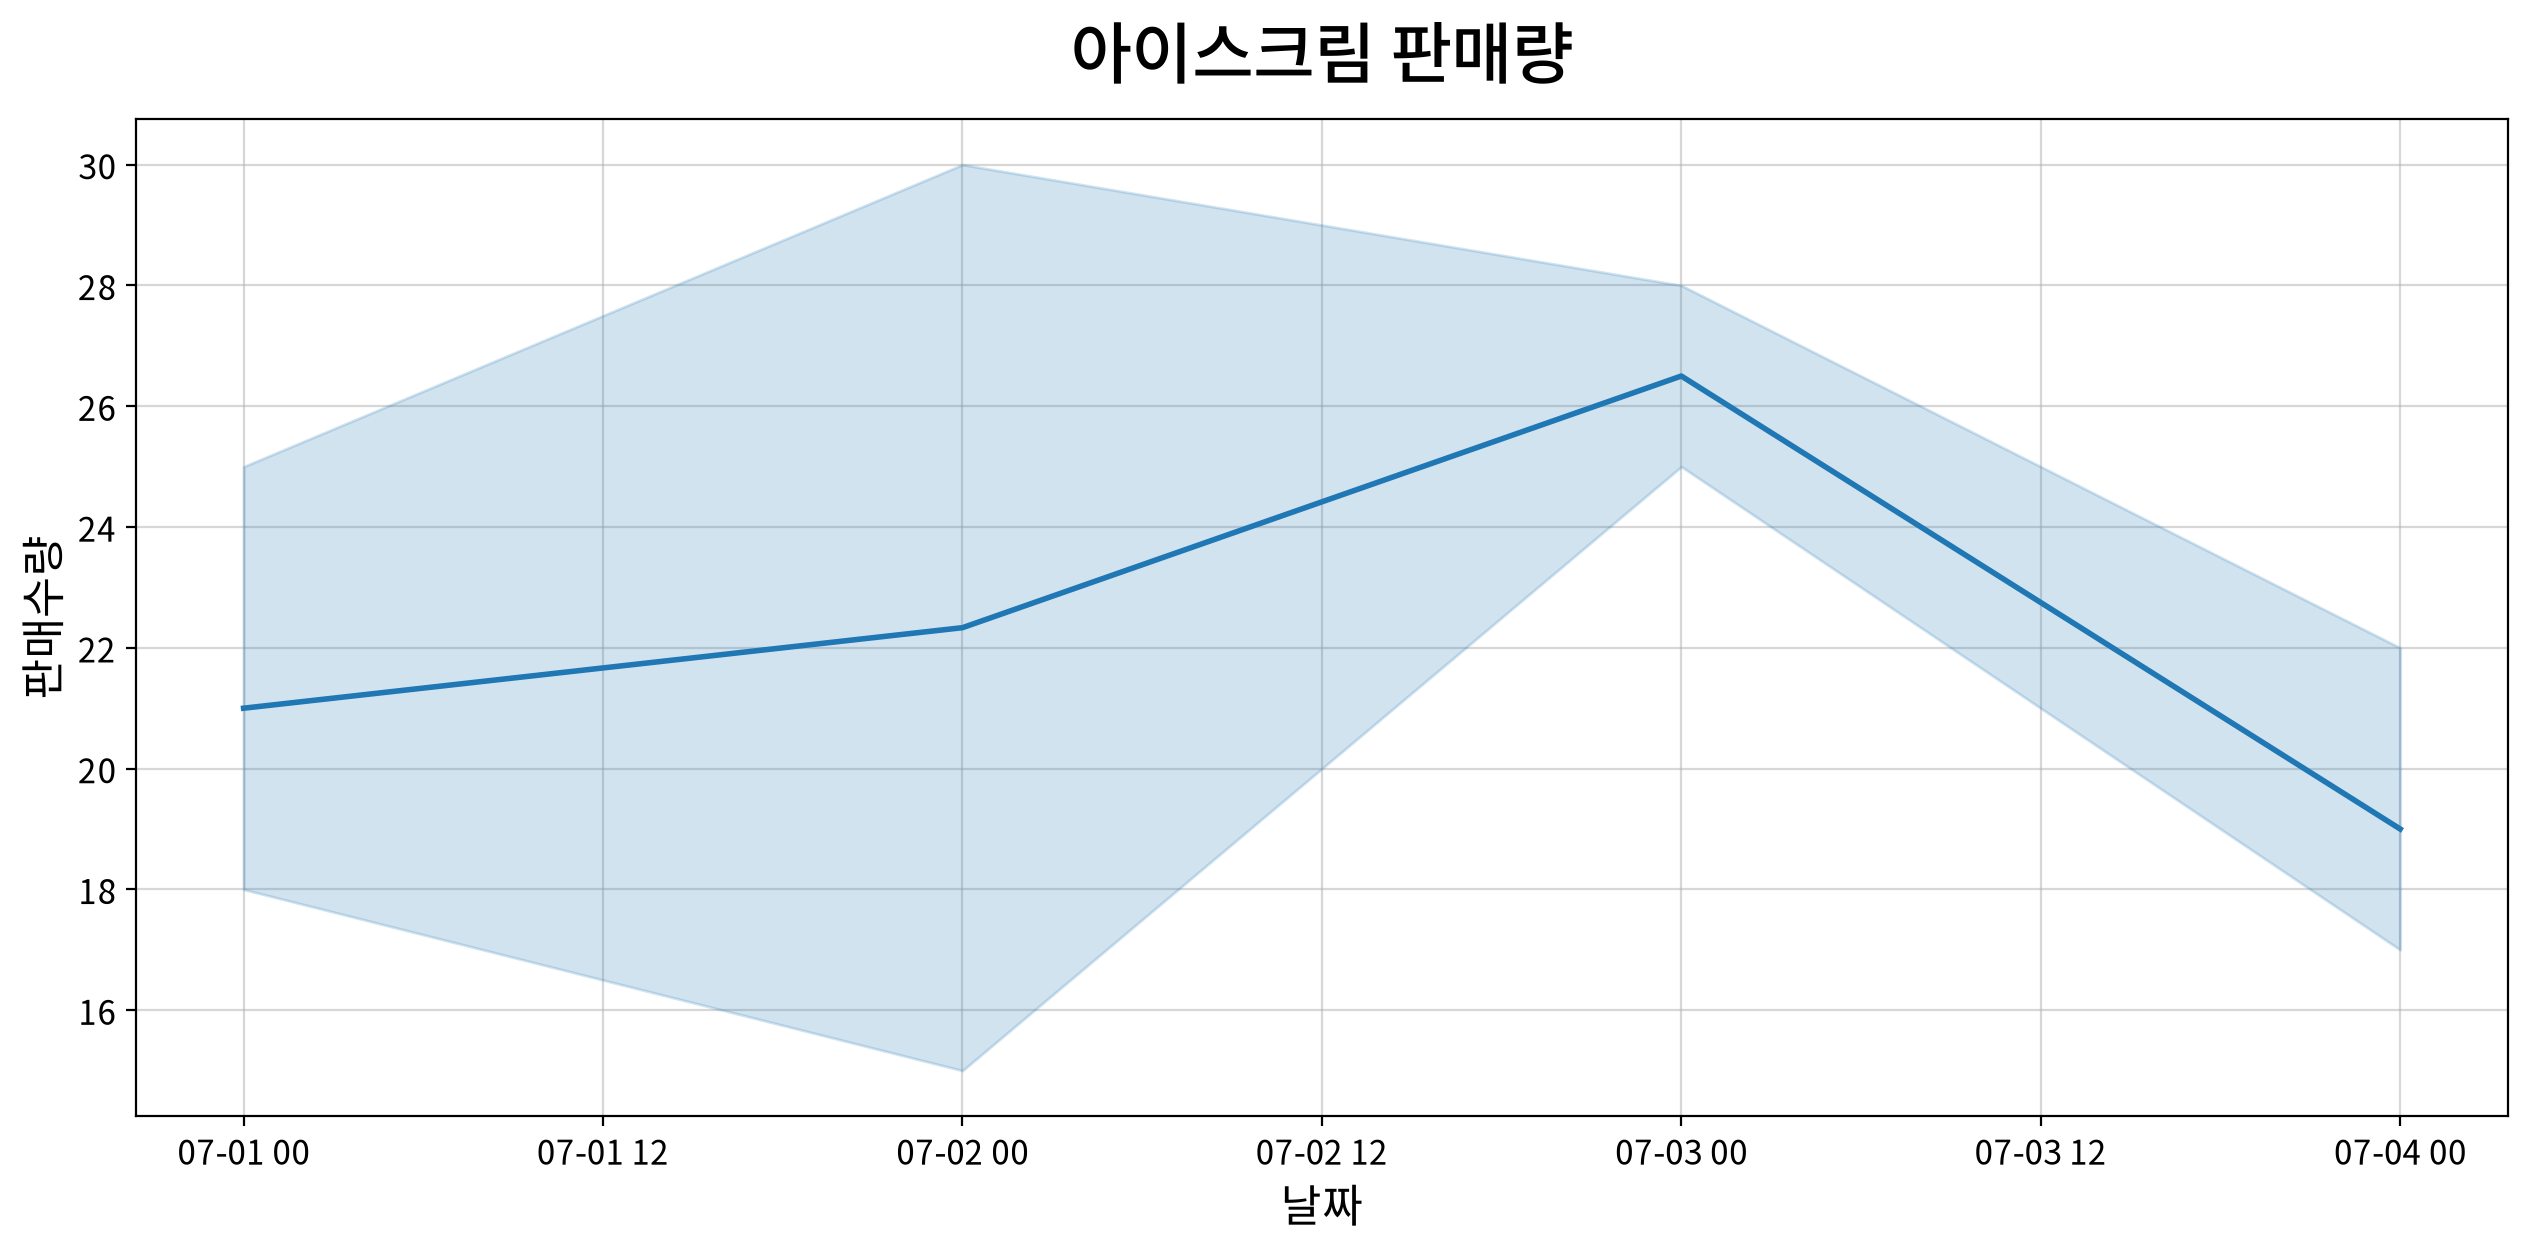

In [5]:
# 그래프 초기화
fig, ax = my_plot.init(title="아이스크림 판매량", 
                       xlabel="날짜", ylabel="판매수량")

# LinePlot 그리기
sb.lineplot(data=origin, x='Date', y="Quantity")

# 출력
my_plot.show()

### 5. DataFrame + 컬럼명 패턴 + hue 파라미터 적용

- `hue` 파라미터에 명목형 변수를 적용하면 집단별로 데이터를 구분하여 시각화 한다.

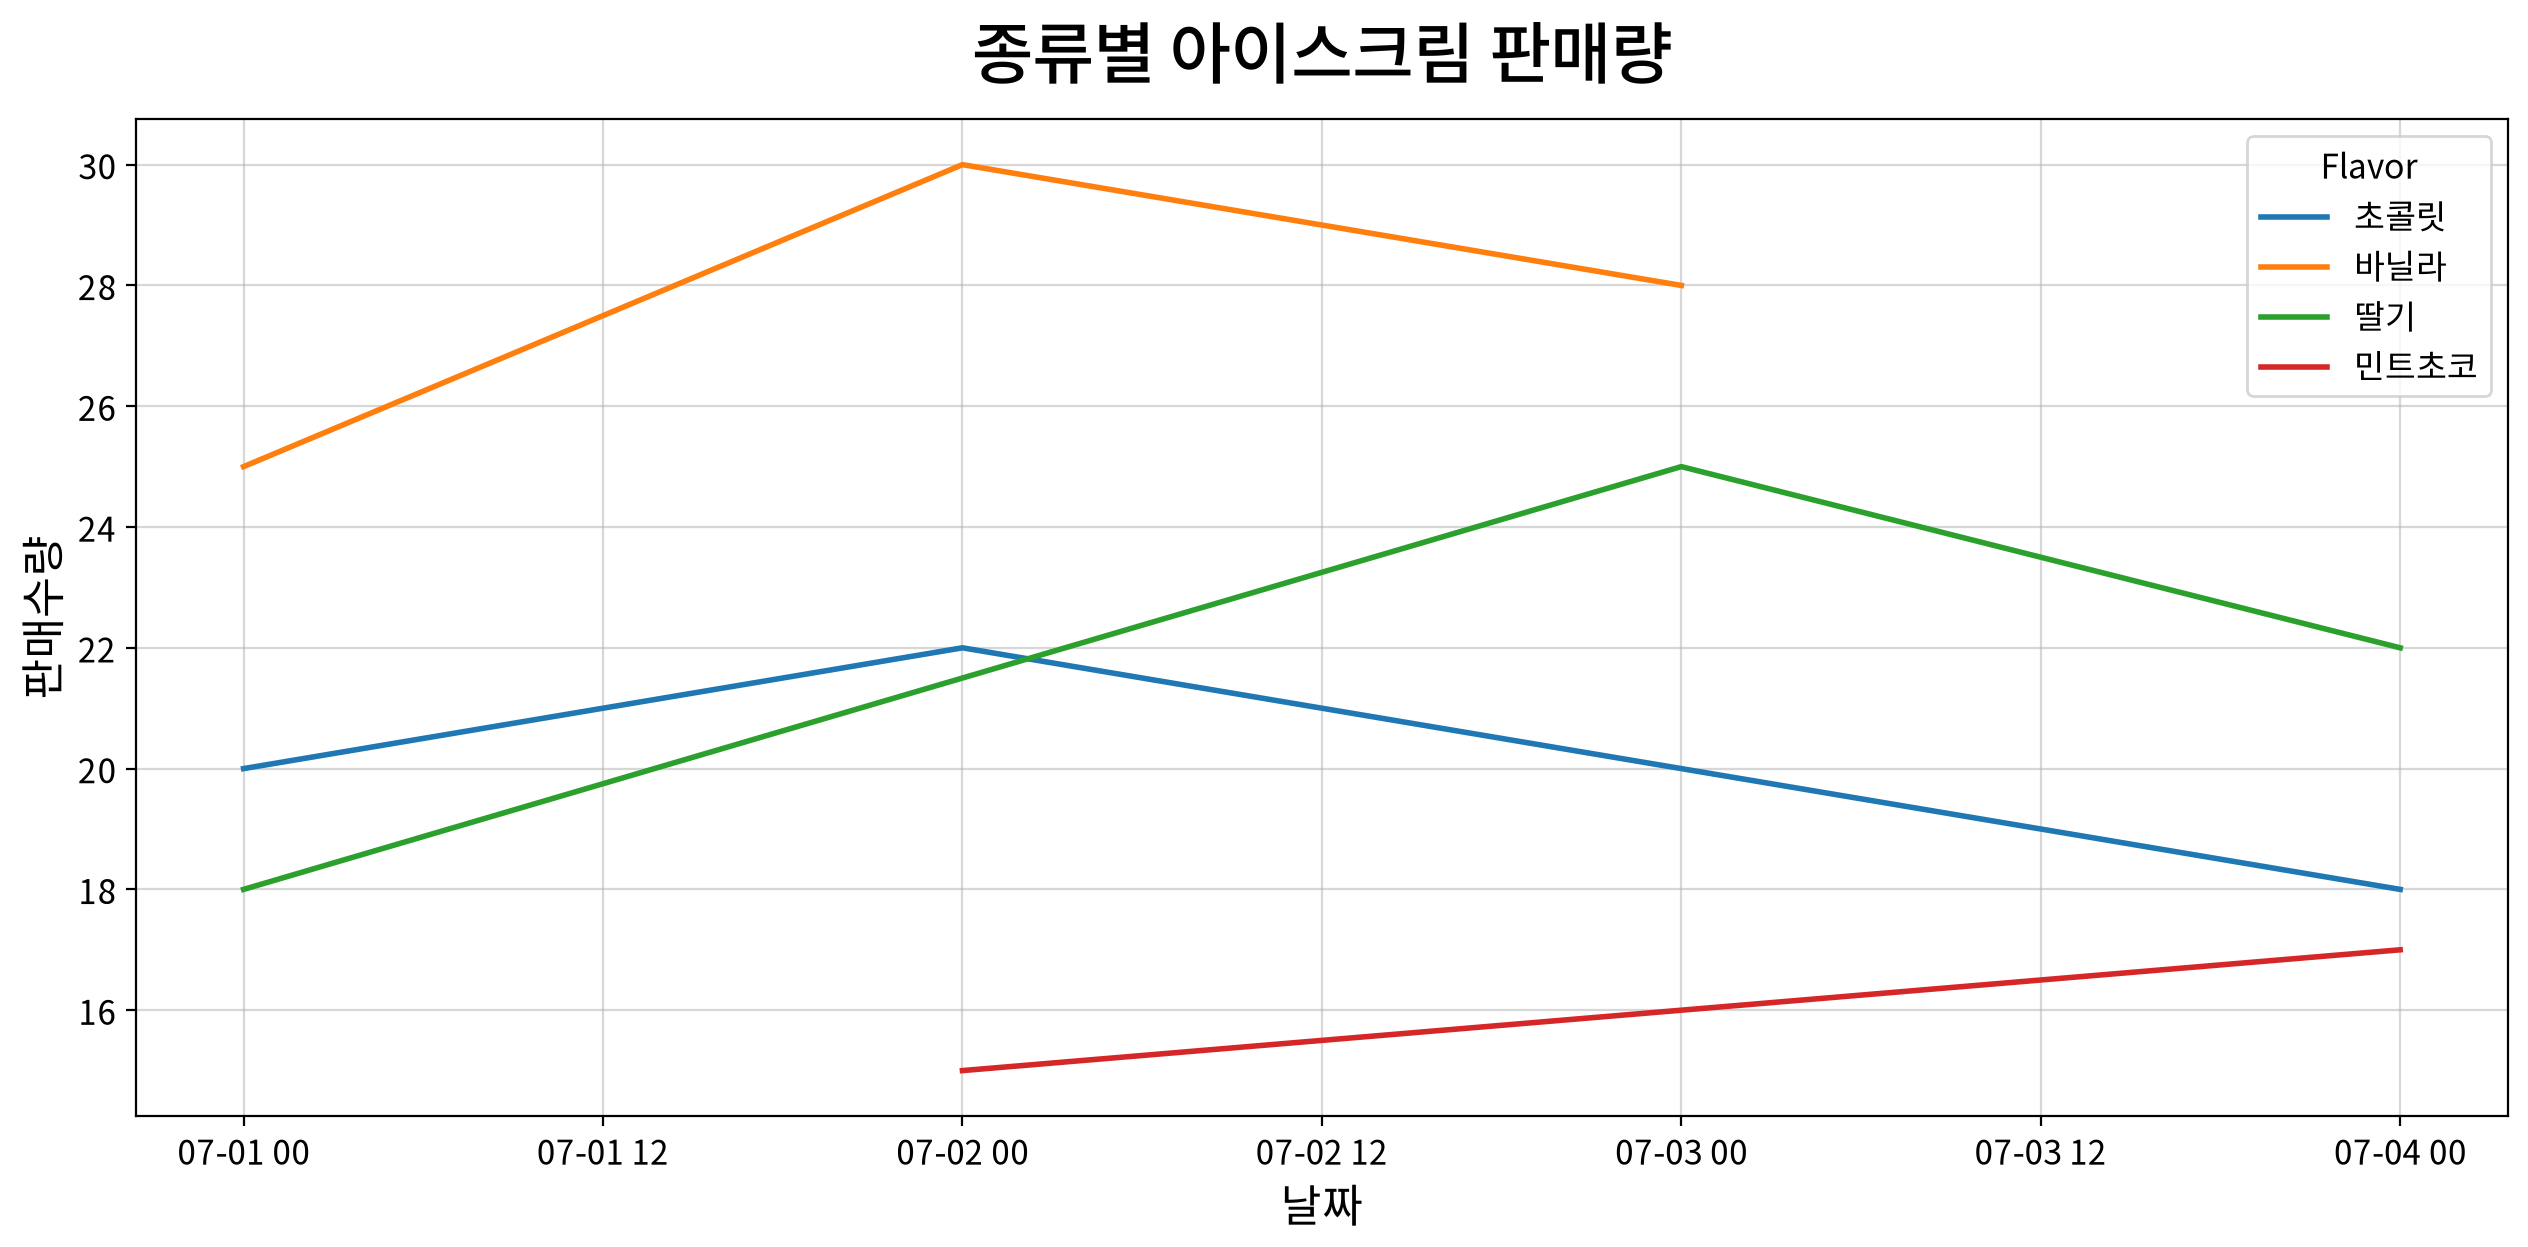

In [6]:
# 그래프 초기화
fig, ax = my_plot.init(title="종류별 아이스크림 판매량", 
                       xlabel="날짜", ylabel="판매수량")

# LinePlot 그리기
sb.lineplot(data=origin, x='Date', y="Quantity", hue="Flavor")

# 출력
my_plot.show()

#### 💡 인사이트

- 바닐라가 전체 구간에서 가장 높은 판매 수준을 유지함
- 바닐라의 최고점은 07-02 시점이며, 그 이후 07-03까지 하락하는 흐름이 확인됨
- 초콜릿은 07-01에서 07-02까지 소폭 증가 후, 07-04까지 연속 하락함
- 딸기는 07-01부터 07-03까지 뚜렷한 상승 뒤 07-04에 하락하는 패턴임
- 초콜릿과 딸기 비교 시, 07-02 이후에는 딸기 판매량이 초콜릿을 상회함
- 민트초코는 표시된 구간(07-02~07-04)에서 매 시점 꾸준히 증가함
- 데이터 표시 기준으로 일부 맛은 모든 날짜에 값이 있지 않음: 바닐라는 3개 시점, 민트초코도 3개 시점만 시각화되어 있음.

### 6. 색상 팔레트 적용

- **palette 파라미터에 팔레트 이름을 지정한다.**
  - 모든 seaborn 함수가 지원한다.
  - 함수에 따라 palette가 아닌 cmap 파라미터로 지원되는 경우도 있음

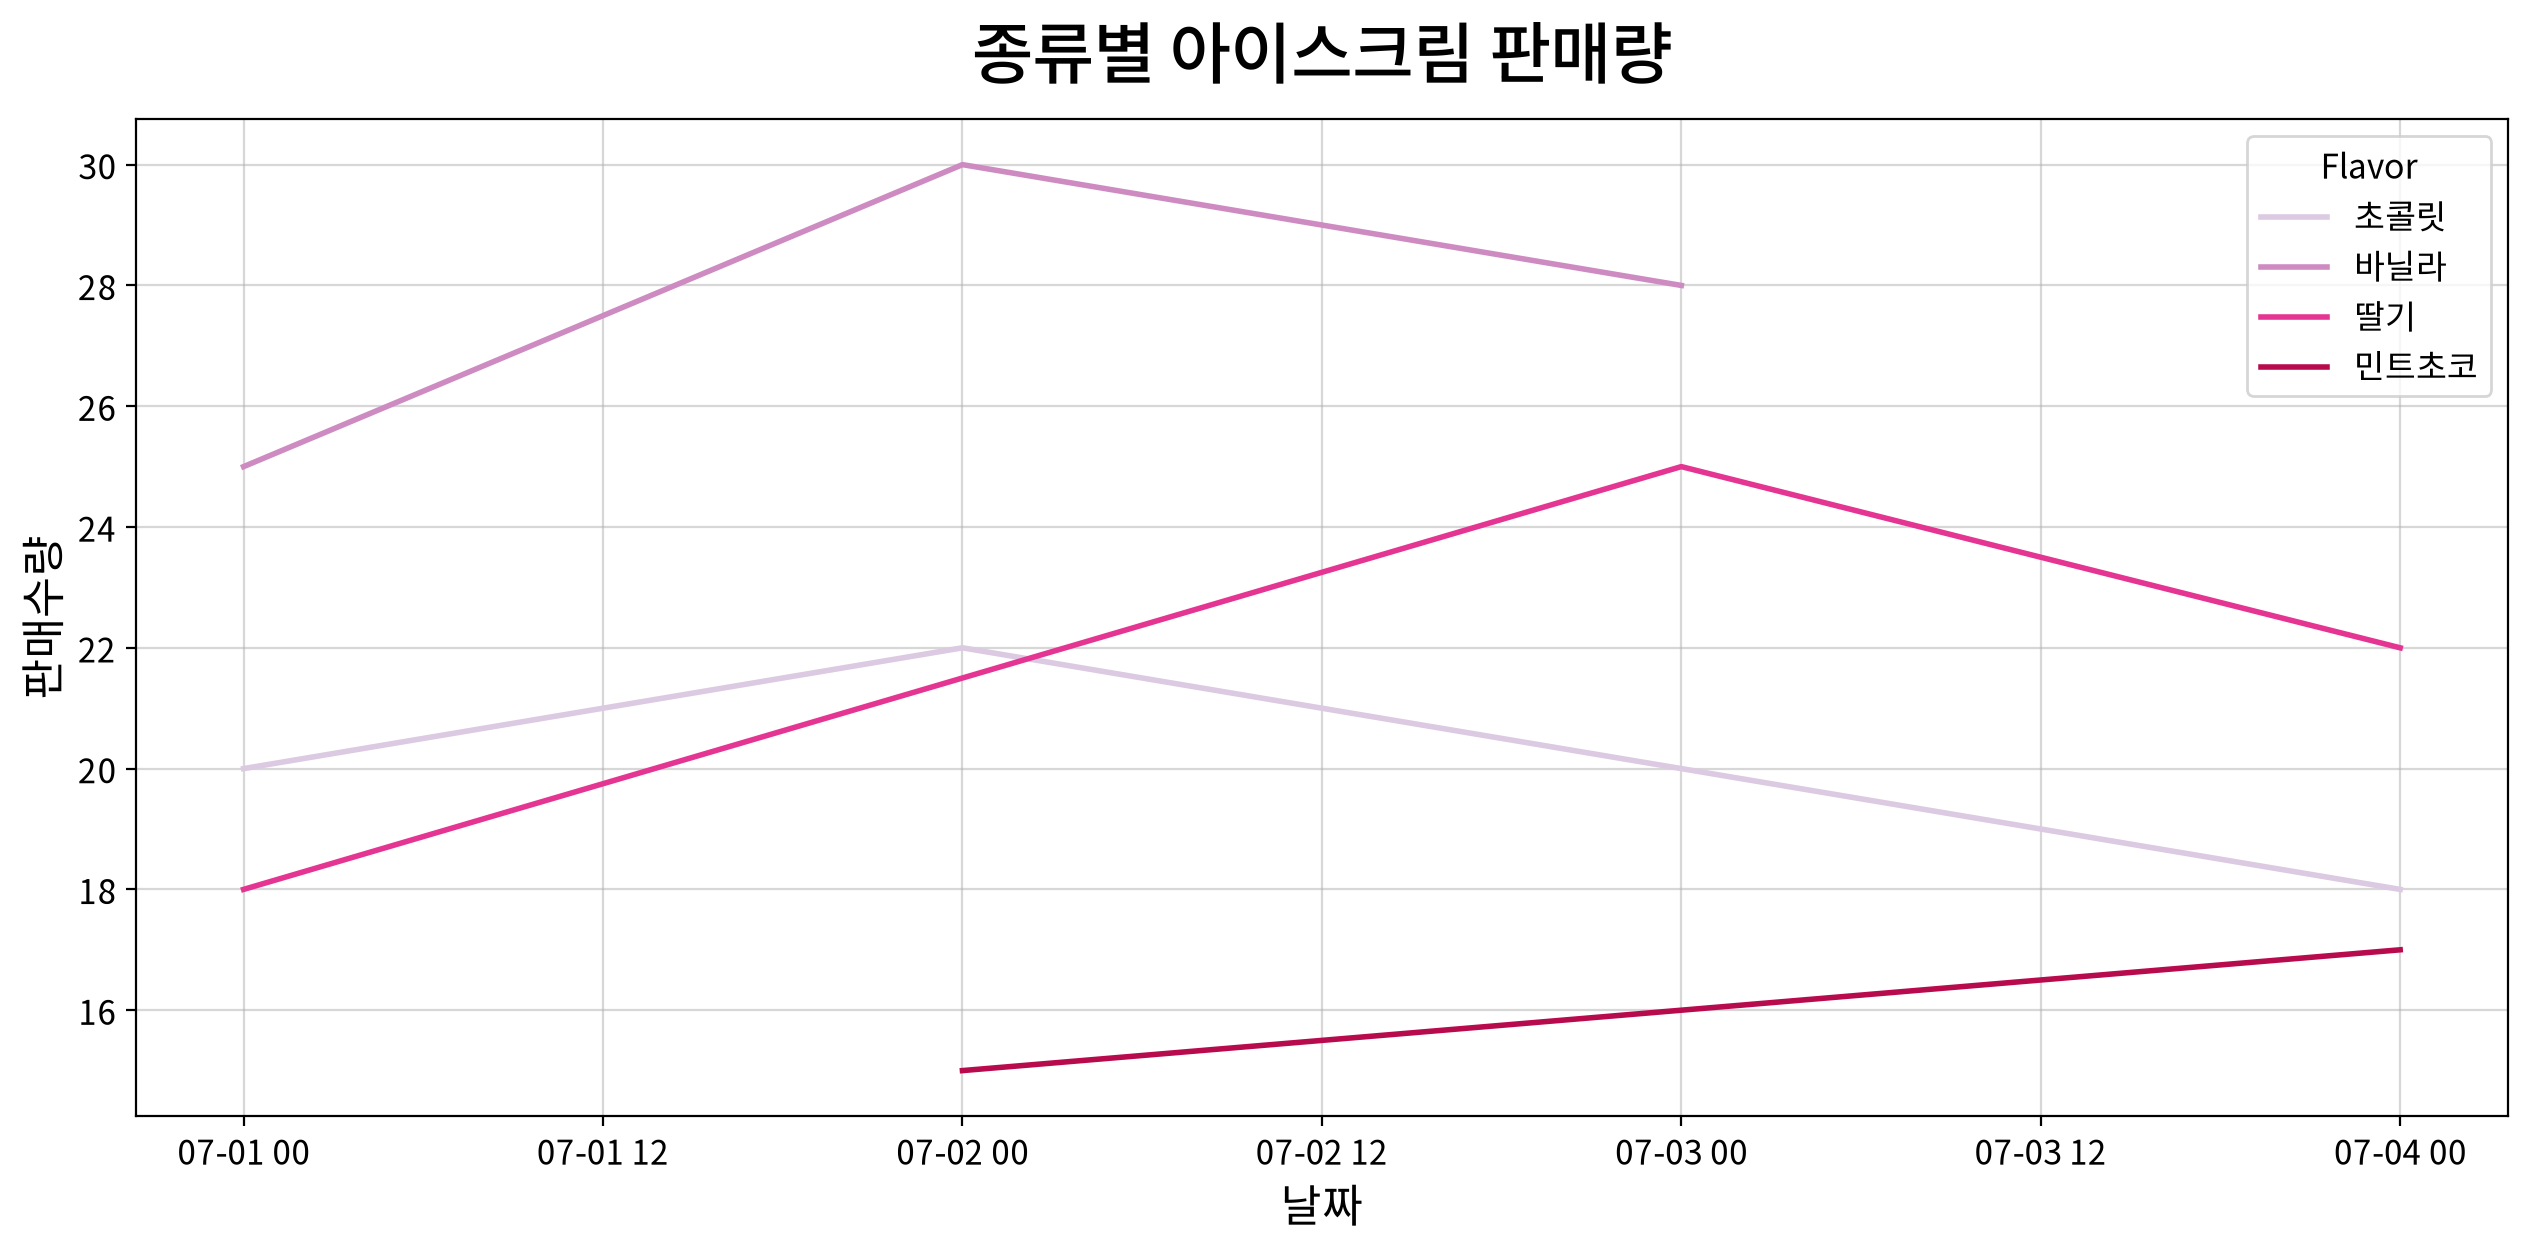

In [7]:
# 그래프 초기화
fig, ax = my_plot.init(title="종류별 아이스크림 판매량", 
                       xlabel="날짜", ylabel="판매수량")

# LinePlot 그리기
sb.lineplot(data=origin, x='Date', y="Quantity", 
            hue="Flavor", palette="PuRd")

# 출력
my_plot.show()